# Digital Systems Components – Model Descriptions

## Nand Gate Model

In [1]:
# The Nand class models the logic behavior of a NAND gate.
class Nand:
    # This method is executed when objects of the Nand class are created.
    def __init__(self):
        # Inputs of the NAND gate
        self.a = 0
        self.b = 0

        # Output of the gate (default = 1 for NAND)
        self.s = 1

    # Receives the input values and executes update.
    def inputs(self, a, b):
        # Assign input values
        self.a = a
        self.b = b

        # Update output after inputs change
        self.update()

    # Computes the output value.
    def update(self):
        # Step 1: AND operation between inputs
        # y = a AND b
        y = self.a & self.b

        # Step 2: NOT operation (invert result)
        # s = NOT(a AND b)
        self.s = 1 - y

    # Returns the output value.
    def output(self):
        return self.s

## Nand class testing

In [2]:
# # Create an instance of the NAND gate. The __init__ method is executed automatically.
nand1 = Nand()

# Provide inputs to the gate: a = 0, b = 1.
# The inputs method executes the update method.
nand1.inputs(0, 1)

# Returns the output value.
# Get the output of the NAND gate
s = nand1.output()

# Displays the output value for inputs 0 and 1.
# NAND(0,1) = 1 because AND(0,1)=0 and NOT(0)=1
s

1

In [3]:
# Create NAND gate instance
nand = Nand()

# All possible input combinations (a, b)
inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]

# Print table header
print("a b | a NAND b ")
print("----|----------")

# Test each combination
for a, b in inputs:
    nand.inputs(a, b)          # Apply inputs
    s = nand.output()          # Get output
    
    # Print result in table format
    print(f"{a} {b} |     {s}")

a b | a NAND b 
----|----------
0 0 |     1
0 1 |     1
1 0 |     1
1 1 |     0


## Combinaciones de entradas con [NumPy](https://numpy.org/)

In [4]:
# Import NumPy for array handling and vectorized operations.
import numpy as np

# Define input arrays representing all combinations of two binary inputs.
a = np.array([0, 0, 1, 1])
b = np.array([0, 1, 0, 1])

# Create an instance of the Nand class.
nand2 = Nand()

# Pass the input arrays to the NAND gate.
# The inputs method assigns values and internally calls update().
nand2.inputs(a, b)

# Retrieve the output array after computation.
s = nand2.output()

# Display the result.
s

array([1, 1, 1, 0])

### pandas

The [pandas](https://pandas.pydata.org/docs/index.html) library "is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language". [DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) "is a two-dimensional, size-mutable, potentially heterogeneous tabular data". A [dictionary](https://docs.python.org/3/tutorial/datastructures.html#dictionaries) "is a data type built into Python".

In [5]:
# Create a dictionary to group input and output signals of the NAND gate.
data = {
    'a': a,        # First input signal (array of binary values).
    'b': b,        # Second input signal (array of binary values).
    'nand': s      # Output signal resulting from the NAND operation.
    }

data

{'a': array([0, 0, 1, 1]),
 'b': array([0, 1, 0, 1]),
 'nand': array([1, 1, 1, 0])}

In [6]:
# Import pandas for tabular data representation.
import pandas as pd

# Convert the dictionary into a DataFrame to visualize it as a truth table.
df = pd.DataFrame(data)
df

,a,b,nand
0,0,0,1
1,0,1,1
2,1,0,1
3,1,1,0


# Nor-based SR Latch

In [7]:
# The SRNor class models an SR latch built with NOR logic gates.
class SRNor:
    # This method is executed when an object is created.
    # It initializes inputs (S, R) and outputs (Q, Q̄).
    def __init__(self):
        self.s = 0      # Set input.
        self.r = 0      # Reset input.
        self.q = 0      # Main output (Q).
        self.qn = 1     # Complementary output (Q̄).

    # Receives input values and triggers state update.
    def inputs(self, s, r):
        self.s = s
        self.r = r
        self.update()

    # Updates the latch state based on SR inputs.
    def update(self):
        # Set condition: S = 1, R = 0 → Q = 1, Q̄ = 0.
        if (self.s == 1) & (self.r == 0):
            self.q = 1
            self.qn = 0

        # Reset condition: S = 0, R = 1 → Q = 0, Q̄ = 1.
        elif (self.s == 0) & (self.r == 1):
            self.q = 0
            self.qn = 1

        # Invalid condition: S = 1, R = 1 → both outputs forced to 0.
        # In real hardware, this is a forbidden/unstable state.
        if (self.s == 1) & (self.r == 1):
            self.q = 0
            self.qn = 0

        # Hold condition (S = 0, R = 0) is implicit:
        # Q and Q̄ retain their previous values.

    # Returns the current outputs of the latch.
    def output(self):
        return self.q, self.qn

In [8]:
# Define input arrays for testing all cases.
s = np.array([0, 0, 0, 1, 0, 1, 0, 1, 0])
r = np.array([0, 1, 0, 0, 0, 1, 0, 0, 0])

# Create an instance of the Nand class.
srlatch = SRNor()

# Initialize output histories.
q, qn = [], []

# Iterate over both input sequences simultaneously (time evolution).
for si, ri in zip(s, r):
    # Apply the current inputs (si, ri) to the SR latch.
    srlatch.inputs(si, ri)

    # Retrieve the updated outputs after state transition.
    qo, qno = srlatch.output()

    # Store outputs to build the waveform (history of Q and Q̄).
    q.append(qo)
    qn.append(qno)

# Show signals.
s, r, q, qn

(array([0, 0, 0, 1, 0, 1, 0, 1, 0]),
 array([0, 1, 0, 0, 0, 1, 0, 0, 0]),
 [0, 0, 0, 1, 1, 0, 0, 1, 1],
 [1, 1, 1, 0, 0, 0, 0, 0, 0])

In [9]:
# Create a dictionary to organize input and output signals of the SR latch.
data = {
    'set': s,     # Set input sequence (S).
    'reset': r,   # Reset input sequence (R).
    'Q': q,       # Main output sequence (Q).
    'Q̄': qn       # Complementary output sequence (Q̄).
    }

# Convert the dictionary into a pandas DataFrame for tabular visualization.
pd.DataFrame(data).T

,0,1,2,3,4,5,6,7,8
set,0,0,0,1,0,1,0,1,0
reset,0,1,0,0,0,1,0,0,0
Q,0,0,0,1,1,0,0,1,1
Q̄,1,1,1,0,0,0,0,0,0


In [10]:
import matplotlib.pyplot as plt

def cronograma(canales, etiquetas, titulo):
    # Create a new figure with a fixed size to emulate an oscilloscope-style display.
    plt.figure(figsize=(8, 4))

    # Time axis: one extra point is added to properly extend the step plot.
    t = range(len(canales[0]) + 1)

    # Vertical offset used to stack multiple digital signals without overlap
    # Starts high and decreases for each channel
    delta = len(canales[0]) * 1.2

    # Iterate over each digital channel and its label
    for canal, etiqueta in zip(canales, etiquetas):
        # Extend signal by repeating last value to maintain step consistency
        w = np.append(canal, [canal[-1]])

        # Plot digital waveform using step representation (oscilloscope style)
        # Each signal is vertically shifted using delta
        plt.step(t, w + delta, where='post', label=etiqueta)

        # Move next signal downward for visual separation
        delta -= 1.2
    
    # Remove y-axis ticks since values are relative (not absolute magnitude)
    plt.yticks([])

    # Define discrete time ticks aligned with signal samples
    plt.xticks(t)

    # Axis labeling for interpretability
    plt.xlabel("Tiempo")

    # Title describing the plotted set of signals
    plt.title(titulo)

    # Display legend mapping each waveform to its label
    plt.legend()

    # Enable grid to improve temporal reference readability
    plt.grid()

    # Render final waveform plot
    plt.show()

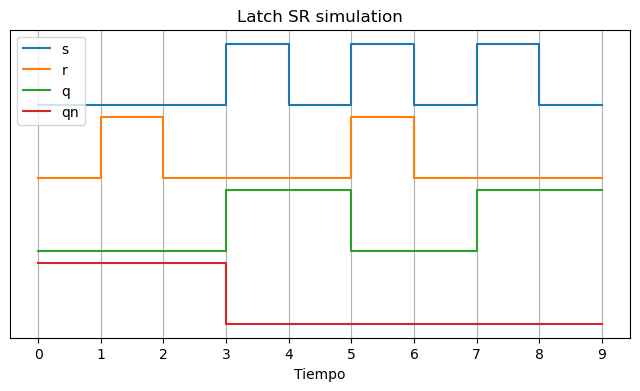

In [11]:
cronograma([s, r, q, qn], ["s", "r", "q", "qn"], "Latch SR simulation")

## 🔷 D Flip-Flop

In [12]:
# The DFlipFlop class models an ideal rising-edge triggered D flip-flop
# with synchronous clear (CLR) and synchronous enable (EN).
class DFlipFlop:
    # Initializes inputs and outputs.
    def __init__(self):
        self.d = 0              # Data input (D).
        
        self.clk = 0            # Current clock value.
        self.clk_prev = 0       # Previous clock value (for edge detection).

        self.en = 0             # Synchronous enable (EN).
        self.clr = 0            # Synchronous clear (CLR), active-high.

        self.q = 0              # Main output (Q).
        self.qn = 1             # Complementary output (Q̄).

    # Receives input values and triggers state update.
    def inputs(self, d, clk, clr, en):
        self.d = d
        self.clk = clk
        self.en = en
        self.clr = clr
        self.update()

    # Updates the flip-flop state based on inputs.
    def update(self):
        # Rising edge condition: CLK transitions from 0 → 1
        if (self.clk_prev == 0) and (self.clk == 1):
            # Priority at clock edge: CLR (reset), EN (load D)
            if self.clr == 1:
                self.q = 0
                self.qn = 1
                
            elif self.en == 1:
                self.q = self.d
                self.qn = 1 - self.d

            # else: hold previous state

        # Update clock history for next cycle
        self.clk_prev = self.clk

        # No rising edge → hold condition:
        # Q and Q̄ retain their previous values.

    # Returns the current outputs of the flip-flop.
    def output(self):
        return self.q, self.qn

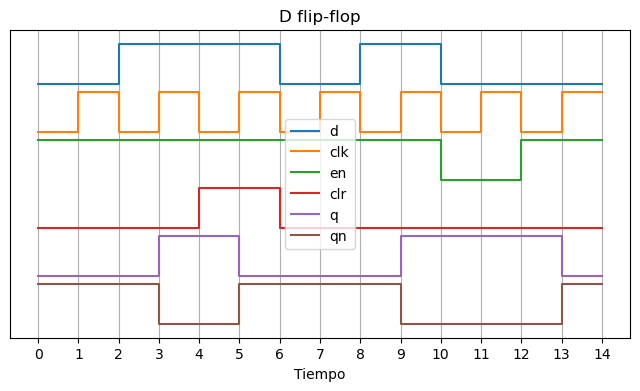

In [13]:
# Input signal D (the data we want to store in the flip-flop)
# Each value represents D at a discrete time step
d = np.array([0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0])

# Clock signal
# Alternates between 0 and 1 to simulate clock transitions
clk = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

# Enable signal
# When en = 1 → the flip-flop is allowed to update
# When en = 0 → the flip-flop holds its previous value
en = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1])

# Clear signal (reset)
# When clr = 1 → output is forced to 0
clr = np.array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

# Create an instance of a D Flip-Flop
dff = DFlipFlop()

# Lists to store output values over time
q = []   # normal output
qn = []  # inverted output

# Iterate through all signals simultaneously
# zip groups corresponding values at each time step
for di, ci, clri, eni in zip(d, clk, clr, en):
    
    # Apply inputs to the flip-flop
    # di   -> data input D
    # ci   -> clock
    # clri -> clear (reset)
    # eni  -> enable
    dff.inputs(di, ci, clri, eni)
    
    # Get the outputs from the flip-flop
    qo, qno = dff.output()
    
    # Store outputs for later analysis
    q.append(qo)
    qn.append(qno)

# Display the timing diagram (waveform)
# Includes all input and output signals
cronograma(
    [d, clk, en, clr, q, qn],
    ["d", "clk", "en", "clr", "q", "qn"],
    "D flip-flop"
)

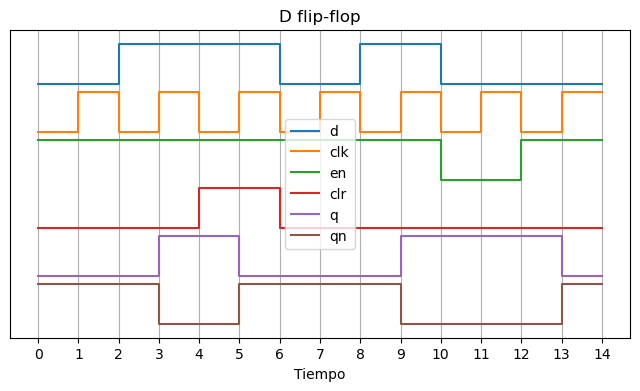

In [14]:
# Input signals (time series)
d   = np.array([0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0])
clk = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])
en  = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1])
clr = np.array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

# Instantiate flip-flop
dff = DFlipFlop()

# Storage
q, qn = [], []

# Time-stepped simulation
for di, ci, clri, eni in zip(d, clk, clr, en):
    dff.inputs(di, ci, clri, eni)
    qo, qno = dff.output()
    q.append(qo)
    qn.append(qno)

cronograma([d, clk, en, clr, q, qn],
           ["d", "clk", "en", "clr", "q", "qn"],
           "D flip-flop")

## 🔷 Register

In [15]:
# The Register class models an n-bit register built from D flip-flops
# with synchronous clear (CLR) and synchronous enable (EN).
class Register:
    def __init__(self, n):
        # Number of bits in the register (e.g., n = 4 → 4-bit register)
        self.n = n
        
        # Create a list of n D Flip-Flops
        # Each flip-flop stores 1 bit
        self.ffs = [DFlipFlop() for _ in range(n)]

    def inputs(self, d, clk, clr=0, en=1):
        # Apply inputs to all flip-flops
        
        # d   → list/array of bits (length must be n)
        # clk → shared clock signal
        # clr → clear (reset), default = 0
        # en  → enable, default = 1
        
        for i in range(self.n):
            # Each flip-flop receives:
            # - one bit from d (d[i])
            # - the same clock
            # - the same clear and enable signals
            self.ffs[i].inputs(d[i], clk, clr, en)

    def output(self):
        # Return the current value stored in the register
        
        # ff.output() returns (q, qn), so we take only q (index 0)
        return [ff.output()[0] for ff in self.ffs]

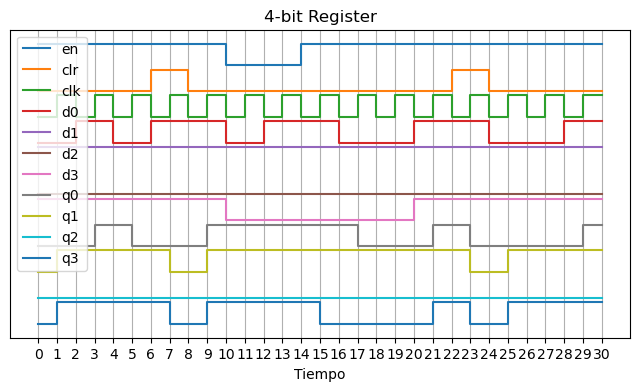

In [16]:
def transpost(data):
    # Transpose a list of lists (rows ↔ columns)
    # Useful to switch between:
    # - signal-wise representation (d0, d1, d2, d3)
    # - time-wise representation ([d0,d1,d2,d3] at each instant)
    return list(map(list, zip(*data)))


# --- INPUT SIGNALS (each is one bit over time) ---

# Bit 0 input over time
d0 = np.array([0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
               0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
               1, 1, 1, 1, 0, 0, 0, 0, 1, 1])

# Bit 1 input (always 1 → useful to observe constant behavior)
d1 = np.array([1]*30)

# Bit 2 input (always 0 → useful as a reference)
d2 = np.array([0]*30)

# Bit 3 input (changes in blocks)
d3 = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
               0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
               1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# Combine bits into a 4-bit word at each time step
# Result: d[t] = [d0[t], d1[t], d2[t], d3[t]]
d = transpost([d0, d1, d2, d3])


# Clock signal (alternating → simulates rising edges)
clk = np.array([0, 1] * 15)

# Enable signal
# When 0 → register holds value
en = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
               0, 0, 0, 0,
               1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

# Clear (reset) signal
# When 1 → register resets to 0
clr = np.array([0, 0, 0, 0, 0, 0,
                1, 1,
                0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                1, 1,
                0, 0, 0, 0, 0, 0])


# --- REGISTER CREATION ---

# Create a 4-bit register (4 flip-flops)
reg = Register(4)

# History of outputs over time
q_hist = []


# --- SIMULATION LOOP (time evolution) ---

for di, ci, clri, eni in zip(d, clk, clr, en):
    
    # Apply inputs at this time step
    # di = [d0, d1, d2, d3]
    reg.inputs(di, ci, clri, eni)
    
    # Store current register output [q0, q1, q2, q3]
    q_hist.append(reg.output())


# Convert history into per-signal format for plotting
q = transpost(q_hist)
d = transpost(d)


# --- TIMING DIAGRAM ---

cronograma(
    [en, clr, clk,
     d[0], d[1], d[2], d[3],
     q[0], q[1], q[2], q[3]],
    
    ["en", "clr", "clk",
     "d0", "d1", "d2", "d3",
     "q0", "q1", "q2", "q3"],
    
    "4-bit Register"
)

## 🔷 Counter

In [17]:
class Counter:
    def __init__(self, max_val):
        # Current and previous clock values (used to detect edges)
        self.clk = 0
        self.prev_clk = 0
        
        # Control signals
        self.clr = 0   # clear (reset)
        self.en = 1    # enable
        
        # Internal state
        self.count = 0  # current counter value
        self.tc = 0     # terminal count flag
        
        # Maximum value (counter wraps after reaching this)
        self.max = max_val

    def inputs(self, clk, clr=0, en=1):
        # Update input signals
        self.clk = clk
        self.clr = clr
        self.en = en
        
        # Update internal state based on new inputs
        self.update()

    def update(self):
        # Detect rising edge: previous clk = 0 and current clk = 1
        if (self.prev_clk == 0) & (self.clk == 1):
            
            # Priority 1: clear (reset)
            if self.clr == 1:
                self.count = 0

            # Priority 2: enable counting
            elif self.en == 1:
                
                # If max value reached → wrap to 0
                if self.count == self.max:
                    self.count = 0
                else:
                    self.count += 1

        # Terminal count signal:
        # tc = 1 when counter reaches max value
        self.tc = (self.count == self.max) & 1
            
        # Store current clock for next edge detection
        self.prev_clk = self.clk

    def output(self):
        # Return:
        # count → current value
        # tc    → terminal count flag
        return self.count, self.tc

In [18]:
def bits(seq: str):
    # Convert a string like "0101" into a list of integers [0,1,0,1]
    return [int(x) for x in seq]


# --- INPUT SIGNALS ---

# Clock signal (alternating → creates rising edges)
clk = bits("01010101010101010101010101010101")

# Enable signal
# Last 4 cycles are 0 → counter should stop updating there
en  = bits("11111111111111111111111111110000")

# Clear signal
# A short pulse in the middle → resets the counter
clr = bits("00000000000000000000001100000000")


# --- STORAGE FOR RESULTS ---

c_hist = []   # counter values over time
tc_hist = []  # terminal count values over time


# --- CREATE COUNTER ---

# Counter that counts from 0 to 9 (mod-10 counter)
c = Counter(9)

# Initial reset (important in simulations!)
# First force clr=1, then release it
c.inputs(0, 1, 1)
c.inputs(1, 1, 1)


# --- SIMULATION LOOP ---

for ci, clri, eni in zip(clk, clr, en):
    
    # Apply inputs at this time step
    c.inputs(ci, clri, eni)
    
    # Store outputs
    count, tc = c.output()
    c_hist.append(count)
    tc_hist.append(tc)


# --- PRINT RESULTS (TIMING VIEW) ---

# Print signals aligned for visual inspection
print('clk: ', ' '.join(map(str, clk)))
print('cnt: ', ' '.join(map(str, c_hist)))
print('tc : ', ' '.join(map(str, tc_hist)))
print('en : ', ' '.join(map(str, en)))
print('clr: ', ' '.join(map(str, clr)))

clk:  0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
cnt:  0 1 1 2 2 3 3 4 4 5 5 6 6 7 7 8 8 9 9 0 0 1 1 0 0 1 1 2 2 2 2 2
tc :  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
en :  1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0
clr:  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0


## 🔷 StopwatchOne

In [19]:
# The StopwatchOne class models a start-stop stopwatch.
class StopwatchOne:
    def __init__(self):
        # Clock signals (used for edge detection)
        self.clk = 0
        self.prev_clk = 0

        # Control inputs
        self.clr = 0     # reset
        self.start = 1   # start signal
        self.stop = 1    # stop signal

        # Internal state
        self.count = 0   # stopwatch value

        # Internal enable (derived from start/stop)
        self.enable = 0

    def inputs(self, clk, start, stop, clr):
        # Update inputs
        self.clk = clk
        self.clr = clr
        self.start = start
        self.stop = stop

        # Update internal behavior
        self.update()

    def update(self):
        # --- CONTROL LOGIC (level-sensitive) ---
        # Start has priority over stop
        if self.start == 1:
            self.enable = 1
        elif self.stop == 1:
            self.enable = 0

        # --- SEQUENTIAL LOGIC (edge-triggered) ---
        # Detect rising edge of clock
        if (self.prev_clk == 0) and (self.clk == 1):

            # Reset has highest priority
            if self.clr == 1:
                self.count = 0

            # Count only if enabled
            elif self.enable == 1:
                self.count += 1

        # Store current clock for next edge detection
        self.prev_clk = self.clk

    def output(self):
        # Return current count value
        return self.count

In [20]:
# Clock signal (alternating → generates rising edges)
clk = bits("01010101010101010101010101010101")

# Start signal
# A short pulse → should enable counting
start = bits("00001100000000000000000000000000")

# Stop signal
# Another pulse later → should disable counting
stop  = bits("00000000000000000000110000000000")

# Clear signal
# Final pulse → should reset the stopwatch
clr   = bits("00000000000000000000000000001100")


# Create stopwatch instance
sw = StopwatchOne()

# Store output history
sw_hist = []


# --- SIMULATION LOOP ---

for clki, starti, stopi, clri in zip(clk, start, stop, clr):
    
    # Apply inputs at this time step
    sw.inputs(clki, starti, stopi, clri)
    
    # Store current count value
    sw_hist.append(sw.output())


# --- PRINT RESULTS (TIMING VIEW) ---

print('clk  :', ' '.join(map(str, clk)))
print('count:', ' '.join(map(str, sw_hist)))
print('start:', ' '.join(map(str, start)))
print('stop :', ' '.join(map(str, stop)))
print('clr  :', ' '.join(map(str, clr)))

clk  : 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
count: 0 0 0 0 0 1 1 2 2 3 3 4 4 5 5 6 6 7 7 8 8 8 8 8 8 8 8 8 8 0 0 0
start: 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
stop : 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0
clr  : 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0


## 🔷 StopwatchTwo

In [21]:
class StopwatchTwo:
    def __init__(self):
        # Clock tracking (for rising edge detection)
        self.clk = 0
        self.prev_clk = 0

        # Control signals
        self.clr = 0
        self.start = 1
        self.stop1 = 1
        self.stop2 = 1

        # Counter values
        self.count1 = 0
        self.count2 = 0

        # Enable flags (control whether each counter runs)
        self.enable1 = 0
        self.enable2 = 0

    def inputs(self, clk, start, stop1, stop2, clr):
        # Update inputs
        self.clk = clk
        self.clr = clr
        self.start = start
        self.stop1 = stop1
        self.stop2 = stop2
        
        # Update system behavior
        self.update()

    def update(self):

        # --- CONTROL LOGIC (LEVEL-SENSITIVE) ---
        # IMPORTANT: This is a PRIORITY chain

        if self.start == 1:
            # Start enables BOTH counters
            self.enable1 = 1
            self.enable2 = 1

        elif self.stop1 == 1:
            # Stop1 disables ONLY counter 1
            self.enable1 = 0

        elif self.stop2 == 1:
            # Stop2 disables ONLY counter 2
            self.enable2 = 0
        
        # --- SEQUENTIAL LOGIC (EDGE-TRIGGERED) ---
        # Rising edge detection
        if (self.prev_clk == 0) and (self.clk == 1):

            # Reset has highest priority
            if self.clr == 1:
                self.count1 = 0
                self.count2 = 0

            else:
                # Increment each counter independently
                if self.enable1 == 1:
                    self.count1 += 1

                if self.enable2 == 1:
                    self.count2 += 1

        # Save clock for next cycle
        self.prev_clk = self.clk

    def output(self):
        return self.count1, self.count2

In [22]:
# Input signals (time series)
clk   = bits("01010101010101010101010101010101")
start = bits("00110000000000000000000000000000")
stop1 = bits("00000000000011000000000000000000")
stop2 = bits("00000000000000000000110000000000")
clr   = bits("00000000000000000000000000001100")

sw = StopwatchTwo()

# Storage
c1 = []
c2 = []

# Simulation loop
for clki, starti, stop1i, stop2i, clri in zip(clk, start, stop1, stop2, clr):
    sw.inputs(clki, starti, stop1i, stop2i, clri)
    x, y = sw.output()
    c1.append(x)
    c2.append(y)

print(' '.join(map(str, clk)))
print(' '.join(map(str, c1)))
print(' '.join(map(str, c2)))
print(' '.join(map(str, start)))
print(' '.join(map(str, stop1)))
print(' '.join(map(str, stop2)))
print(' '.join(map(str, clr)))

0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
0 0 0 1 1 2 2 3 3 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 0 0 0
0 0 0 1 1 2 2 3 3 4 4 5 5 6 6 7 7 8 8 9 9 9 9 9 9 9 9 9 9 0 0 0
0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0


In [23]:
# Distances (in the same units, e.g., meters)
d1 = 300
d2 = 700

# Experimental data:
# (reference acceleration, time to reach d1, time to reach d2)
data = [
    ( 1, 14.1, 25.8),
    ( 2, 10.0, 18.3),
    ( 5,  6.3, 11.5),
    (10,  4.5,  8.2),
    (15,  3.6,  6.6),
    (20,  3.1,  5.7),
    (25,  2.9,  5.2),
    (30,  2.6,  4.8),
    (40,  2.3,  4.1),
    (50,  2.0,  3.6)
]

# Lists to store results
acceleration = []  # computed accelerations
error = []         # percentage errors


# --- MAIN LOOP ---

for a_ref, t1, t2 in data:
    
    # Compute acceleration using:
    # a = 2 * (d2/t2 - d1/t1) / (t2 - t1)
    #
    # This comes from kinematics:
    # position under constant acceleration:
    # d = do + vo * t + (1/2) * a * t^2
    #
    # Here we are combining two measurements (d1, t1) and (d2, t2)
    # to calculate acceleration.
    a = 2 * (d2/t2 - d1/t1) / (t2 - t1)
    
    # Compute percentage error relative to reference value
    # e = (measured / reference - 1) * 100
    e = (a / a_ref - 1) * 100

    # Print formatted result
    print(f"Aceleración: {a:6.2f} ({a_ref:>2}), error: {e:6.2f} %")
    
    # Store results
    acceleration.append(a)
    error.append(abs(e))  # absolute error (magnitude only)

Aceleración:   1.00 ( 1), error:   0.09 %
Aceleración:   1.99 ( 2), error:  -0.59 %
Aceleración:   5.10 ( 5), error:   1.93 %
Aceleración:  10.11 (10), error:   1.08 %
Aceleración:  15.15 (15), error:   1.01 %
Aceleración:  20.03 (20), error:   0.13 %
Aceleración:  27.10 (25), error:   8.41 %
Aceleración:  27.68 (30), error:  -7.73 %
Aceleración:  44.77 (40), error:  11.94 %
Aceleración:  55.56 (50), error:  11.11 %


In [24]:
a_ref = [1, 2, 5, 10, 15, 20, 25, 30, 40, 50]

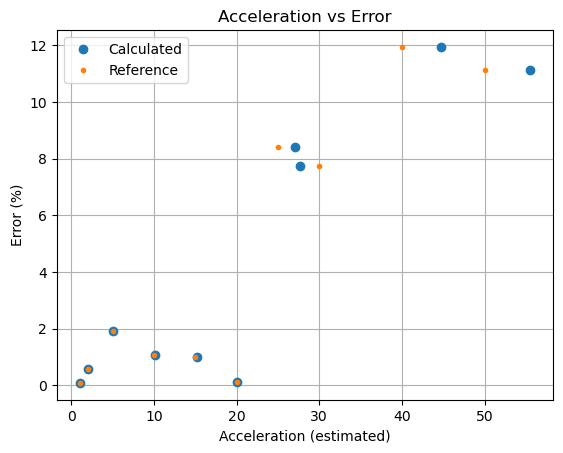

In [25]:
# Plot the data as individual points ('o' means circle markers)
# x-axis → estimated acceleration
# y-axis → percentage error
plt.plot(acceleration, error, 'o', label='Calculated')
plt.plot(a_ref, error, '.', label='Reference')

# Label for the horizontal axis
# Indicates these are computed (not reference) acceleration values
plt.xlabel("Acceleration (estimated)")

# Label for the vertical axis
# Shows how far the estimate is from the true value in %
plt.ylabel("Error (%)")

# Title of the graph
# Summarizes what relationship is being visualized
plt.title("Acceleration vs Error")
plt.legend()
# Add a grid to make it easier to read values and trends
plt.grid()

# Display the plot on screen
plt.show()

# 🧩 Reflection

### ❓ Questions
- What is the difference between combinational and sequential logic?
- Why is a clock necessary in these systems?
- What are the limitations of level-sensitive control?
- How would you redesign the stopwatch to behave like a real device?

### 🧪 Challenge
- Modify one class to use edge-triggered control (detect button press instead of level):
- Explain how the behavior changes.